# Pengujian

#### setup lagi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os 

# Setup path untuk import dari src folder
loc = os.getcwd()
root = os.path.dirname(loc)
srcPath = os.path.join(root, "src")
sys.path.insert(0, srcPath)

from ffnn.model import FFNN
from ffnn.utils.activation_function import Linear, ReLU, Sigmoid, Tanh, Softmax
from ffnn.utils.loss_function import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from ffnn.utils.initialization import ZeroInit, UniformInit, NormalInit, XavierInit, HeInit
from ffnn.utils.regularizer import L1, L2
from ffnn.plot import plotTrainingHistory, plotWeightDistribution, plotGradientDistribution

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)


#### pickle 

In [2]:
# dataPath = Path.cwd().parent / 'data' / 'datasetml_2026.csv'
# data = pd.read_csv(dataPath)

# data['placement_status'] = data['placement_status'].map({
#     'Placed': 1,
#     'Not Placed': 0
# })

# catCols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
# data = pd.get_dummies(data, columns=catCols, drop_first=True)

# X = data.drop('placement_status', axis=1).values.astype(float)
# y = data['placement_status'].values.reshape(-1, 1).astype(float)

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# meanX = X_train.mean(axis=0)
# stdX = X_train.std(axis=0) + 1e-8
# X_train = (X_train - meanX) / stdX
# X_val = (X_val - meanX) / stdX

# print(f'X_train shape: {X_train.shape}')
# print(f'X_val shape: {X_val.shape}')
# print(f'y_train shape: {y_train.shape}')
# print(f'y_val shape: {y_val.shape}')

# ambil dari pickle  
import pickle 
import os
loc = os.getcwd()
models  = os.path.join(loc, 'models')
with open(os.path.join(models, 'processedData.pkl'), 'rb') as f:  
    data = pickle.load(f)

# with open('processedData.pkl', 'rb') as f:  
#     data = pickle.load(f)

print(data)

Xtr = data['X_train']
Xte = data['X_test']
ytr = data['y_train']
yte = data['y_test']

if (Xtr is not None) and (Xte is not None) and (ytr is not None) and (yte is not None):
    print(f'Xtr shape: {Xtr.shape}')
    print(f'Xte shape: {Xte.shape}')
    print(f'ytr shape: {ytr.shape}')
    print(f'yte shape: {yte.shape}')

{'X_train':           cgpa  backlogs  internship_count  aptitude_score  \
1575  0.385195 -1.099921          1.745749        1.854680   
786   0.686205  0.679576          0.717950        0.809427   
4348 -0.045942  0.679576          1.745749       -1.609019   
8411 -0.437796  1.569325          1.745749       -0.653170   
8650 -0.396835 -0.210172         -1.337648       -0.690039   
...        ...       ...               ...             ...   
6526 -0.302160 -0.210172          0.717950       -1.134934   
922   0.545952  0.679576         -0.309849       -1.043985   
4705 -0.260639 -1.099921         -0.309849        0.218275   
3572 -2.264060  0.679576         -0.309849       -0.972783   
6512 -2.169449 -0.210172          0.717950       -1.186435   

      communication_score  internship_quality_score  college_tier_Tier 1  \
1575            -0.596811                  0.840215                  0.0   
786              1.099136                  1.591018                  0.0   
4348           

c:\Users\MSI\Desktop\ml\tubes-1\feed-forward-neural-network\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##### Config

In [3]:
Xtr = Xtr.values if hasattr(Xtr, 'values') else Xtr
Xte = Xte.values if hasattr(Xte, 'values') else Xte
ytr = ytr.values.reshape(-1, 1) if hasattr(ytr, 'values') else ytr
yte = yte.values.reshape(-1, 1) if hasattr(yte, 'values') else yte

print(f'After conversion:')
print(f'Xtr type: {type(Xtr)}, shape: {Xtr.shape}')
print(f'Xte type: {type(Xte)}, shape: {Xte.shape}')
print(f'ytr type: {type(ytr)}, shape: {ytr.shape}')
print(f'yte type: {type(yte)}, shape: {yte.shape}')

widthConfigs = [
    [Xtr.shape[1], 8, 4, 1],
    [Xtr.shape[1], 16, 8, 1],
    [Xtr.shape[1], 32, 16, 1]
]

depthConfigs = [
    [Xtr.shape[1], 16, 1],
    [Xtr.shape[1], 16, 16, 1],
    [Xtr.shape[1], 16, 16, 16, 1]
]

After conversion:
Xtr type: <class 'numpy.ndarray'>, shape: (7356, 28)
Xte type: <class 'numpy.ndarray'>, shape: (1839, 28)
ytr type: <class 'numpy.ndarray'>, shape: (7356, 1)
yte type: <class 'numpy.ndarray'>, shape: (1839, 1)


In [4]:
baseConfig = [Xtr.shape[1], 16, 16, 1]
activationChoices = [Linear(), ReLU(), Sigmoid(), Tanh()]
activationNames = ['Linear', 'ReLU', 'Sigmoid', 'Tanh']

In [5]:
learningRates = [0.001, 0.01, 0.1]

In [6]:
regularizers = [None, L1(0.001), L2(0.001)]
regNames = ['No Reg', 'L1', 'L2']
baseConfig2 = [Xtr.shape[1], 16, 16, 1]

In [7]:
modelConfig = [Xtr.shape[1], 16, 16, 1]

#### Pengujian : Hyperparameter

#### Konfigurasi Width dan Depth  masing masing [1]

In [8]:
widthResults = {}

for config in widthConfigs:
    name = f'Width {config[1]}-{config[2]}'
    model = FFNN(
        layer_sizes=config,
        activations=[ReLU(), ReLU(), Sigmoid()],
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=L2(0.001)
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
    ypr = model.predict(Xte)
    yclassPred = (ypr > 0.5).astype(int)
    acc = accuracy_score(yte, yclassPred)
    
    widthResults[name] = {
        'model': model,
        'history': history,
        'akurasi': acc
    }
    
    print(f'{name}: akurasi = {acc:.4f}')

Width 8-4: akurasi = 0.7384
Width 16-8: akurasi = 0.7314
Width 32-16: akurasi = 0.7395


In [9]:
depthResults = {}

for config in depthConfigs:
    depth = len(config) - 1
    name = f'Depth {depth}'
    
    activations = [ReLU()] * (depth - 1) + [Sigmoid()] # rumus activations = skema aktivasi layer
    model = FFNN(
        layer_sizes=config,
        activations=activations,
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=L2(0.001)
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
    ypr = model.predict(Xte)
    yclassPred = (ypr > 0.5).astype(int)
    acc = accuracy_score(yte, yclassPred)
    depthResults[name] = {
        'model': model,
        'history': history,
        'akurasi': acc
    }
    print(f'{name}: akurasi = {acc:.4f}')



Depth 2: akurasi = 0.7249
Depth 3: akurasi = 0.7374
Depth 4: akurasi = 0.7308


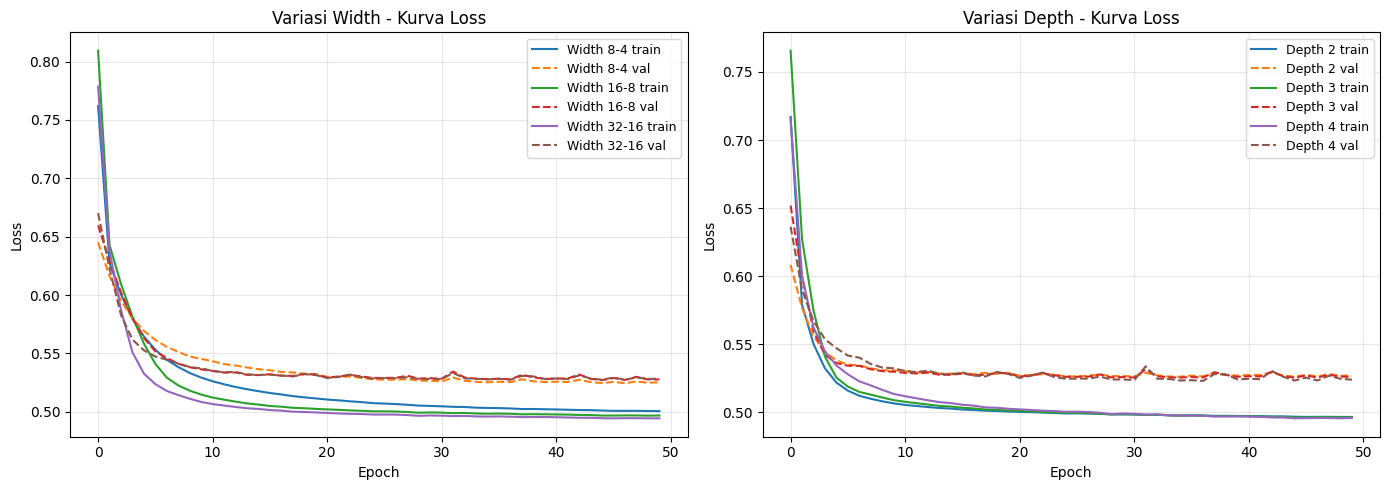


PEMBAHASAN [1]

Width:
  Width 16-8: 0.7314
  Width 32-16: 0.7395
  Width 8-4: 0.7384

Depth:
  Depth 2: 0.7249
  Depth 3: 0.7374
  Depth 4: 0.7308


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in widthResults.items():
    axes[0].plot(result['history']['train_loss'], label=f'{name} train')
    axes[0].plot(result['history']['val_loss'], label=f'{name} val', linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Variasi Width - Kurva Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, result in depthResults.items():
    axes[1].plot(result['history']['train_loss'], label=f'{name} train')
    axes[1].plot(result['history']['val_loss'], label=f'{name} val', linestyle='--')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Variasi Depth - Kurva Loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPEMBAHASAN [1]')
print('\nWidth:')
for name in sorted(widthResults.keys()):
    print(f"  {name}: {widthResults[name]['akurasi']:.4f}")
print('\nDepth:')
for name in sorted(depthResults.keys()):
    print(f"  {name}: {depthResults[name]['akurasi']:.4f}")


#### Konfigurasi fungsi aktivasi [2]

In [11]:
activationResults = {}

for actName, act in zip(activationNames, activationChoices):
    model = FFNN(
        layer_sizes=baseConfig,
        activations=[act, ReLU(), Sigmoid()],  # test layer 0
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=L2(0.001)
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0) 
    # epoh = 50 
    # learning rate = 0.01
    # batch size = 32
    # 
    
    ypr = model.predict(Xte)
    ypredClass = (ypr > 0.5).astype(int)
    acc = accuracy_score(yte, ypredClass)
    
    activationResults[actName] = {
        'model': model,
        'history': history,
        'akurasi': acc
    }
    print(f'{actName}: akurasi = {acc:.4f}')

Linear: akurasi = 0.7341
ReLU: akurasi = 0.7374
Sigmoid: akurasi = 0.7390
Tanh: akurasi = 0.7357


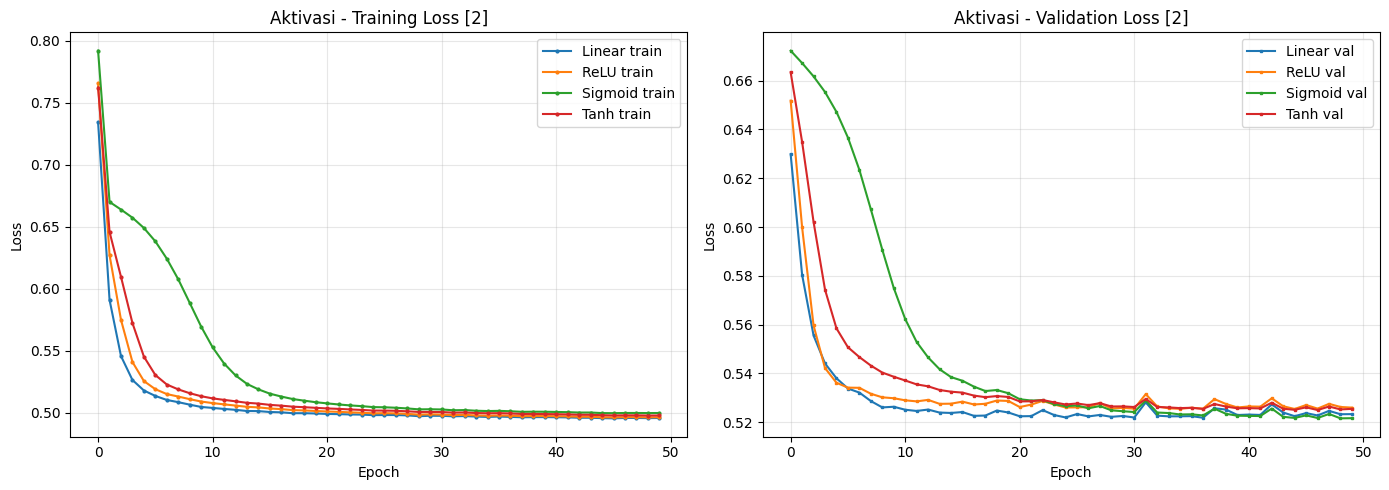


Linear - Distribusi Bobot:


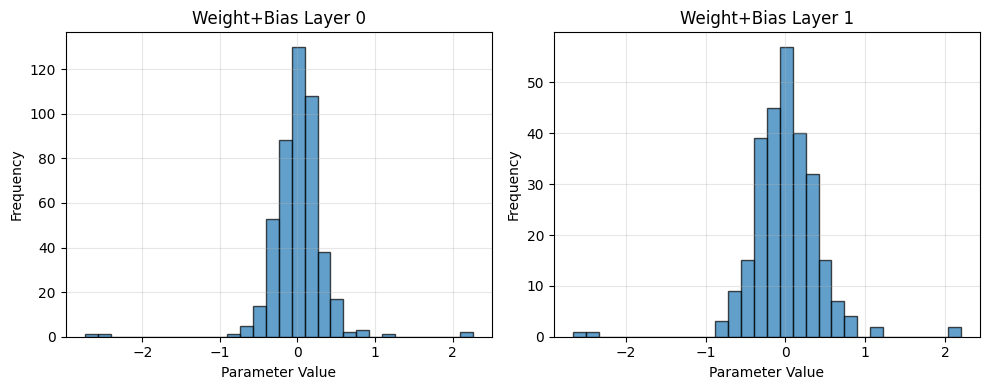


Linear - Distribusi Gradien:


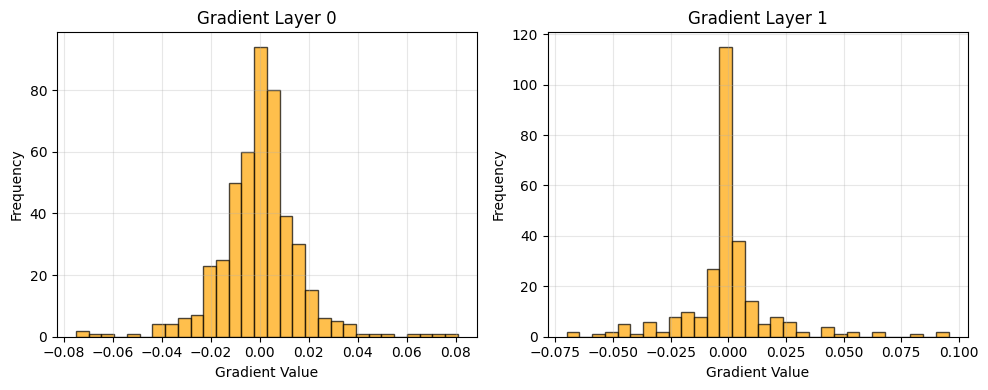


ReLU - Distribusi Bobot:


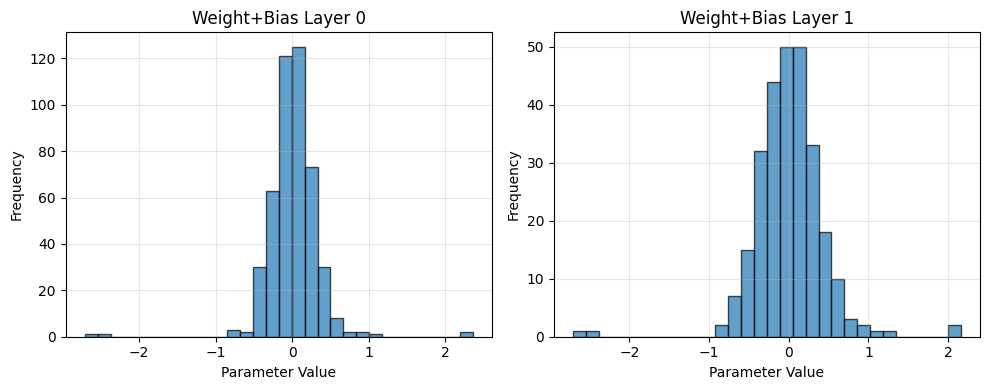


ReLU - Distribusi Gradien:


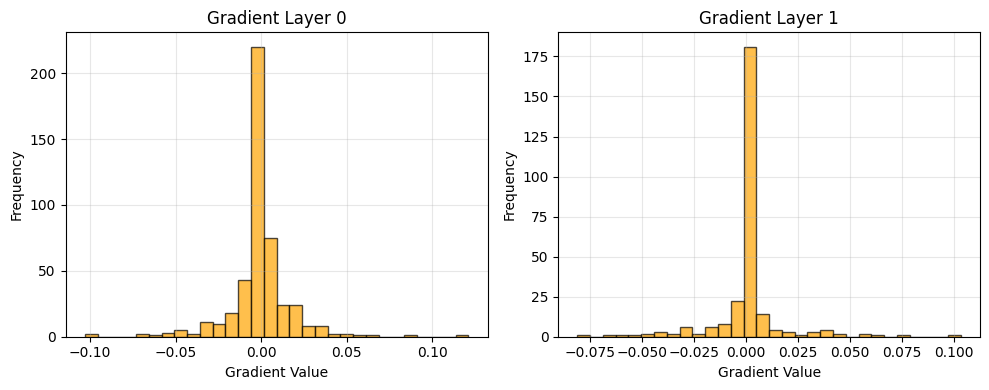


Sigmoid - Distribusi Bobot:


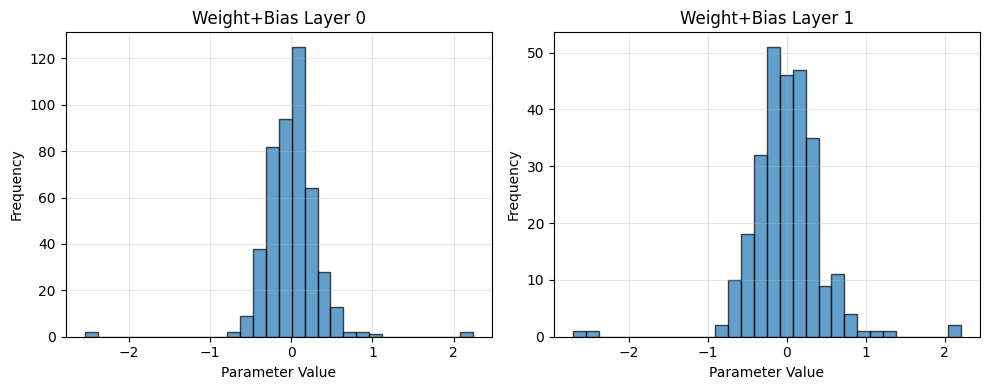


Sigmoid - Distribusi Gradien:


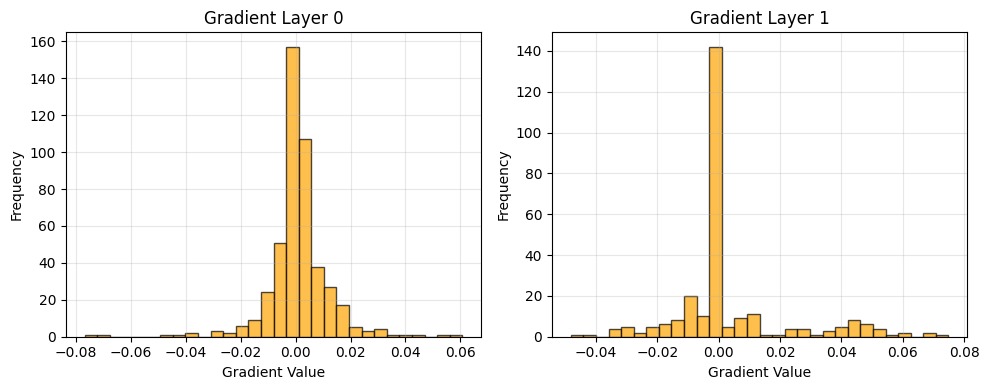


Tanh - Distribusi Bobot:


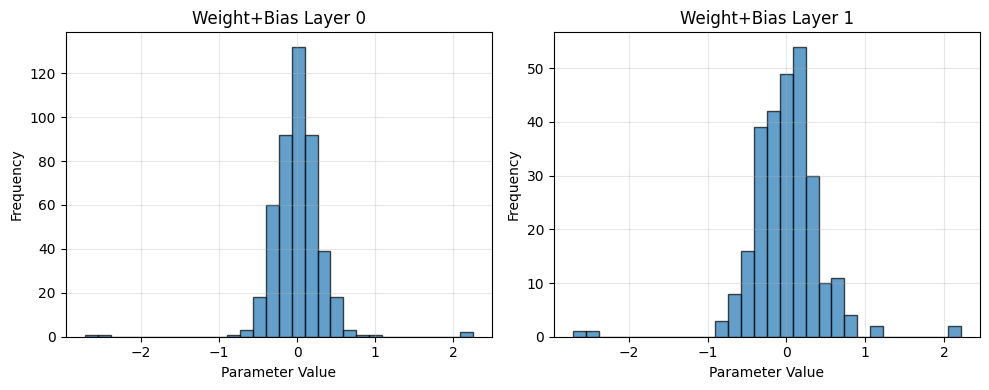


Tanh - Distribusi Gradien:


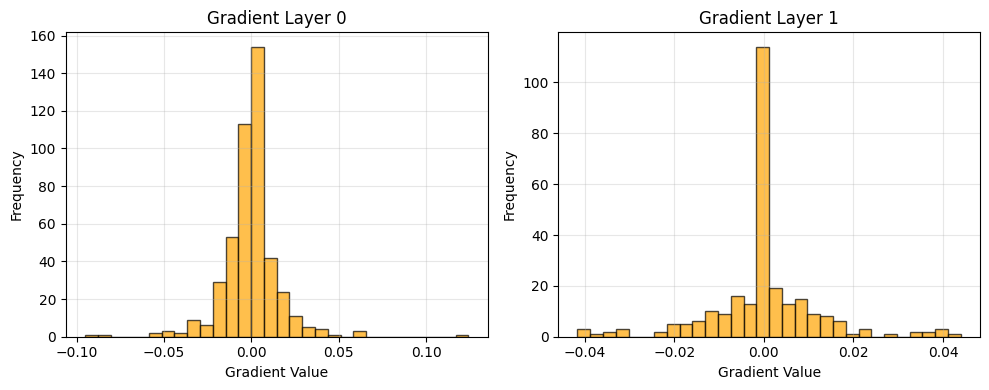

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in activationResults.items():
    axes[0].plot(result['history']['train_loss'], label=f'{name} train', marker='o', markersize=2)
    axes[1].plot(result['history']['val_loss'], label=f'{name} val', marker='s', markersize=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Aktivasi - Training Loss [2]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Aktivasi - Validation Loss [2]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for name, result in activationResults.items():
    print(f'\n{name} - Distribusi Bobot:')
    result['model'].plotWeightDistribution(layerIndices=[0, 1])

    print(f'\n{name} - Distribusi Gradien:')
    result['model'].plotGradientDistribution(layerIndices=[0, 1])

#### Konfigurasi Learning rate [3]

In [13]:
lrResults = {}

for lr in learningRates:
    model = FFNN(
        layer_sizes=baseConfig,
        activations=[ReLU(), ReLU(), Sigmoid()],
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=L2(0.001) 
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=100, lr=lr, batch_size=32, verbose=0)
    ypr = model.predict(Xte)
    ypredClass = (ypr > 0.5).astype(int)
    acc = accuracy_score(yte, ypredClass)
    
    lrResults[f'lr={lr}'] = {
        'model': model,
        'history': history,
        'akurasi': acc
    }
    
    print(f'Learning Rate {lr}: akurasi = {acc:.4f}')

Learning Rate 0.001: akurasi = 0.7401
Learning Rate 0.01: akurasi = 0.7330
Learning Rate 0.1: akurasi = 0.7281


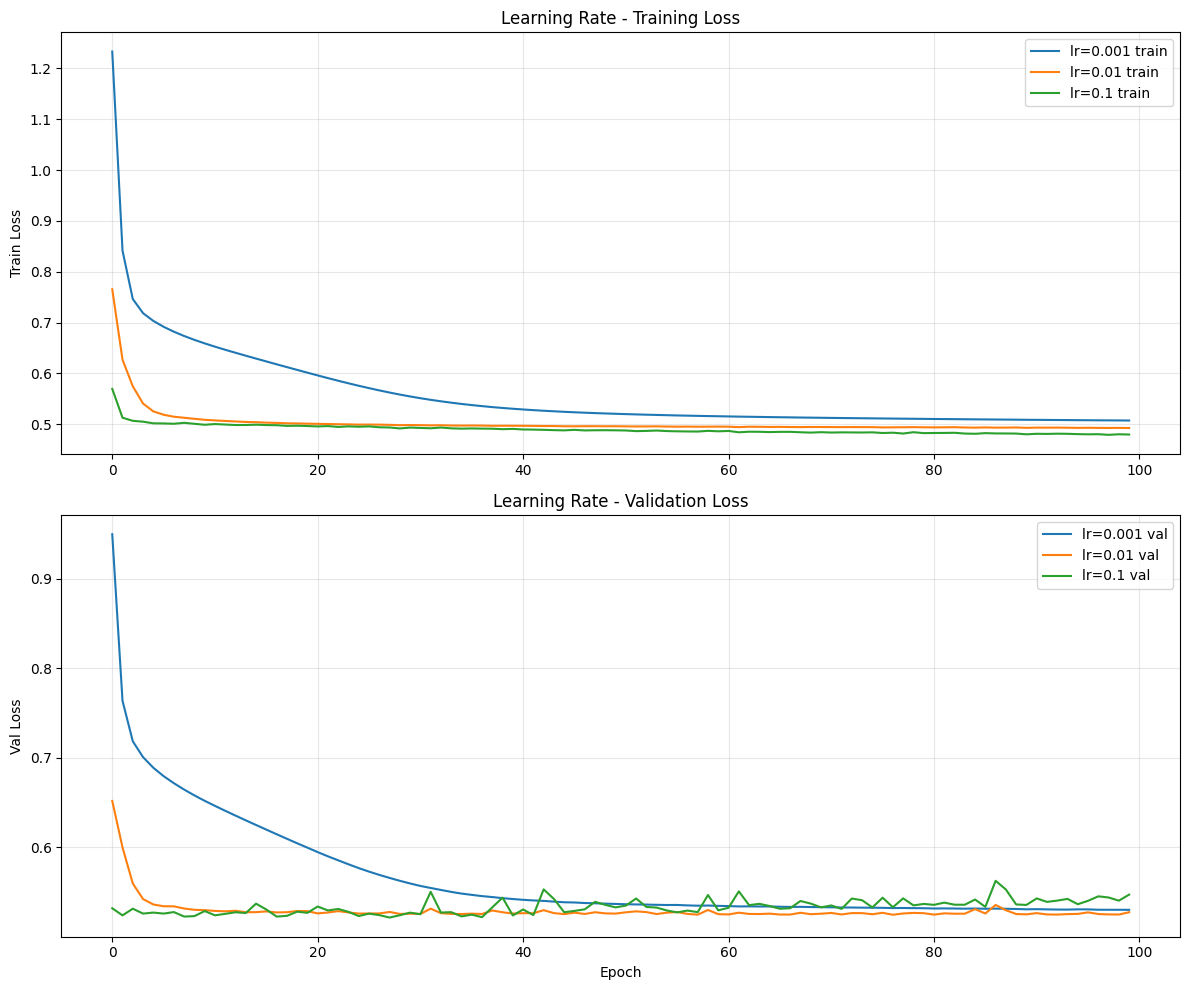


=== PEMBAHASAN [3] ===
lr=0.001: akurasi = 0.7401
lr=0.01: akurasi = 0.7330
lr=0.1: akurasi = 0.7281

lr=0.001 - Distribusi Bobot:


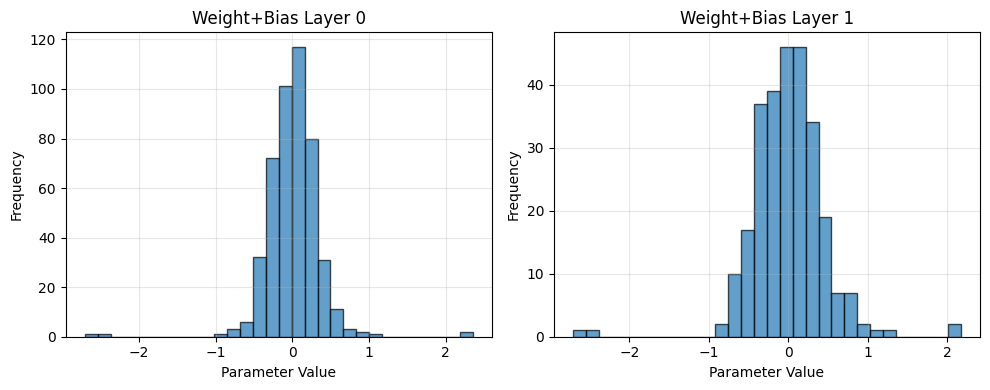


lr=0.001 - Distribusi Gradien:


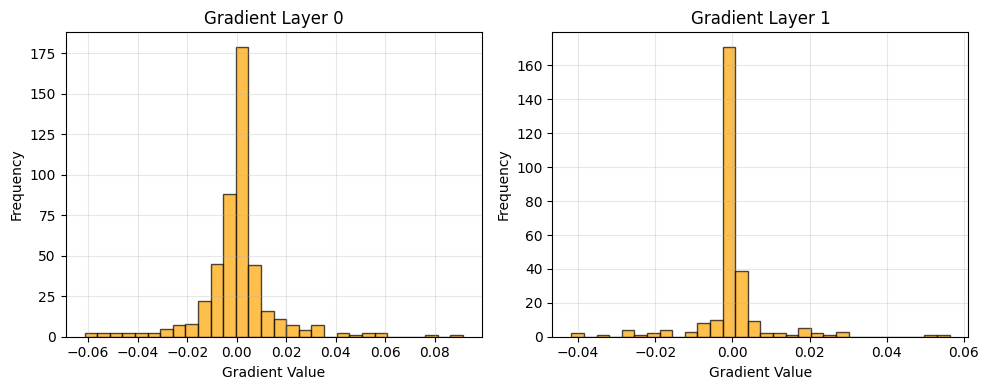


lr=0.01 - Distribusi Bobot:


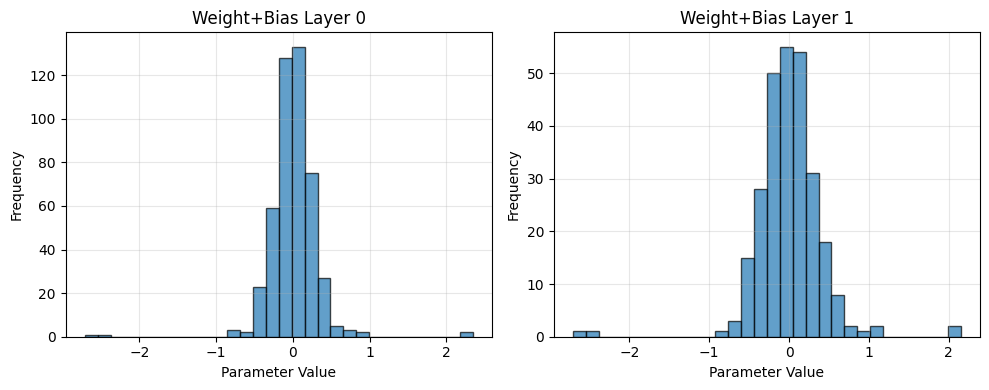


lr=0.01 - Distribusi Gradien:


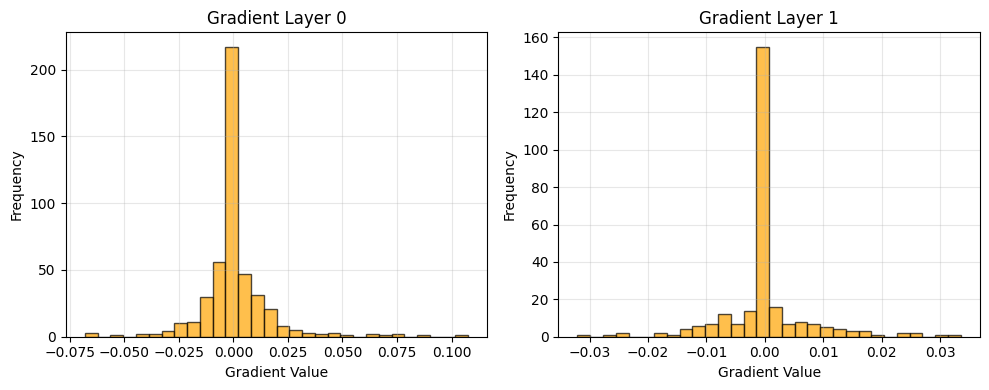


lr=0.1 - Distribusi Bobot:


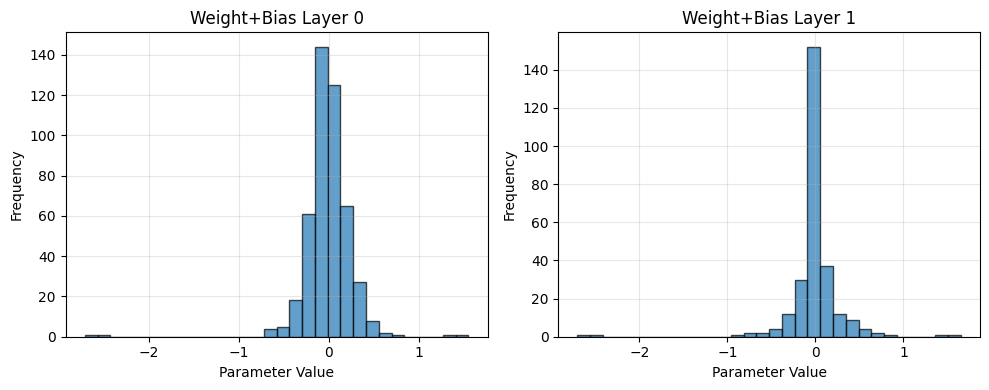


lr=0.1 - Distribusi Gradien:


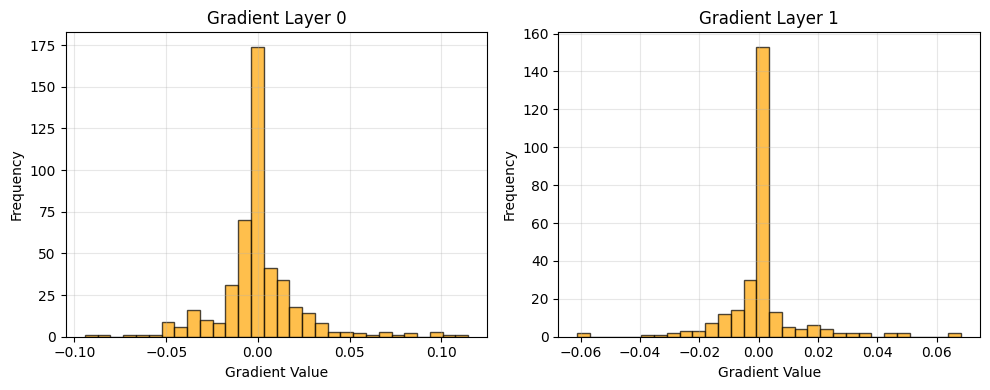

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for name, result in lrResults.items():
    axes[0].plot(result['history']['train_loss'], label=f'{name} train')
    axes[1].plot(result['history']['val_loss'], label=f'{name} val')

axes[0].set_ylabel('Train Loss')
axes[0].set_title('Learning Rate - Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Learning Rate - Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== PEMBAHASAN [3] ===')
for name, result in lrResults.items():
    print(f'{name}: akurasi = {result["akurasi"]:.4f}')

for name, result in lrResults.items():
    print(f'\n{name} - Distribusi Bobot:')
    result['model'].plotWeightDistribution(layerIndices=[0, 1])

    print(f'\n{name} - Distribusi Gradien:')
    result['model'].plotGradientDistribution(layerIndices=[0, 1])

#### Konfigurasi Regularisasi [4]

In [15]:
regResults = {}

for name, reg in zip(regNames, regularizers):
    model = FFNN(
        layer_sizes=baseConfig2,
        activations=[ReLU(), ReLU(), Sigmoid()],
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=reg
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
    # epoh = 50 
    # learning rate = 0.01
    ypr = model.predict(Xte)
    ypredClass = (ypr > 0.5).astype(int)
    acc = accuracy_score(yte, ypredClass)
    
    regResults[name] = {
        'model': model,
        'history': history,
        'akurasi': acc
    }
    
    print(f'{name}: akurasi = {acc:.4f}')

No Reg: akurasi = 0.7357
L1: akurasi = 0.7336
L2: akurasi = 0.7374


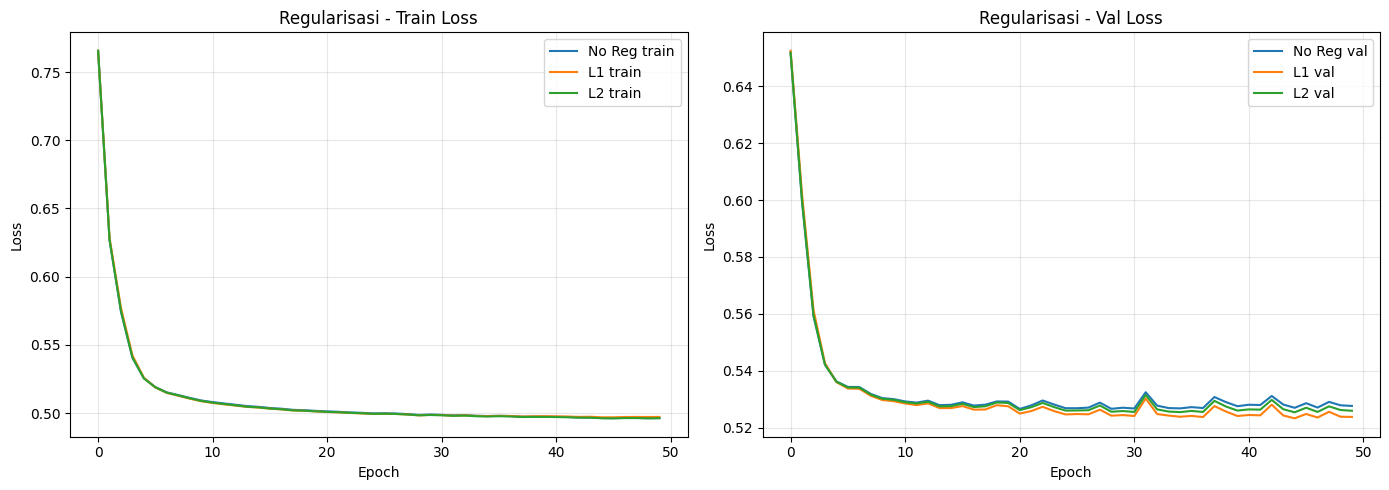


No Reg - Distribusi Bobot:


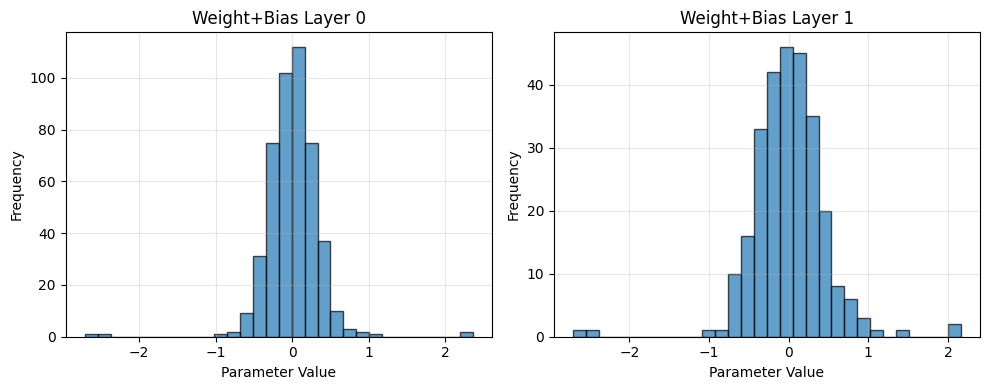


No Reg - Distribusi Gradien:


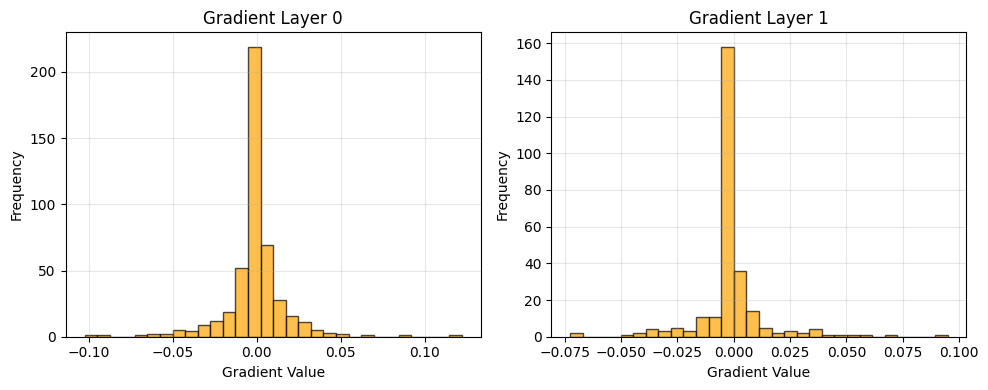


L1 - Distribusi Bobot:


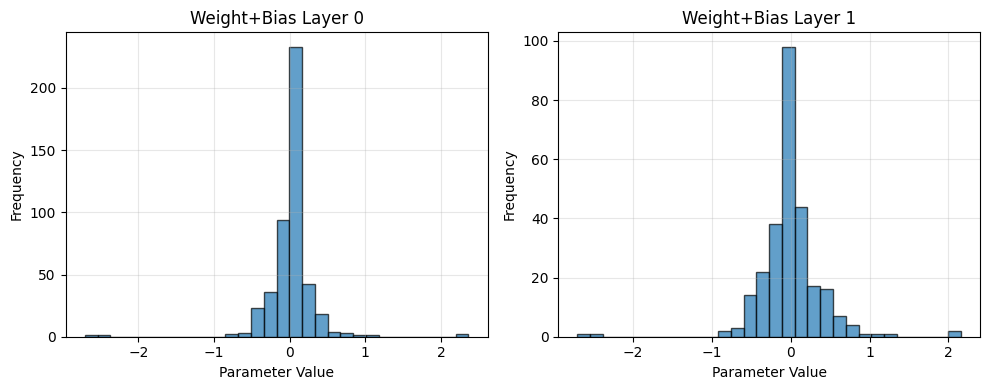


L1 - Distribusi Gradien:


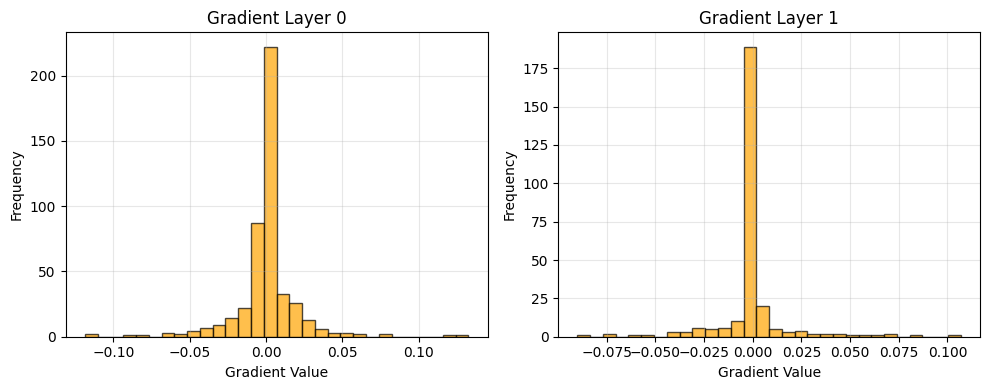


L2 - Distribusi Bobot:


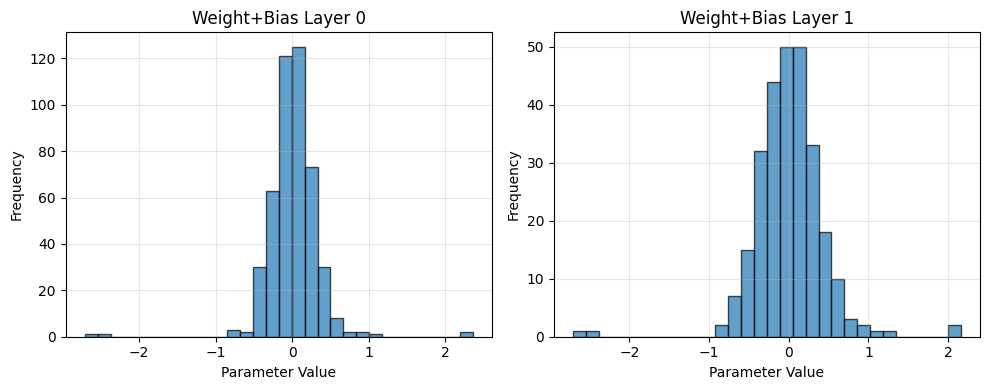


L2 - Distribusi Gradien:


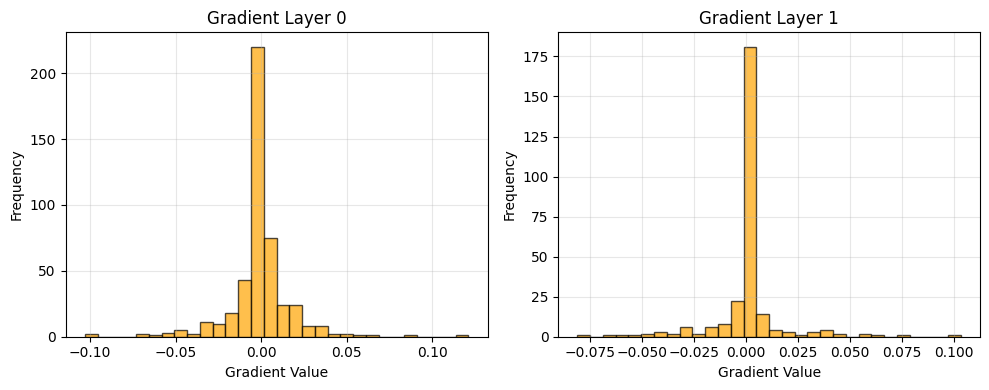


No Reg - Bobot layer 0:
  Rataan: 0.009133, Std: 0.260111

L1 - Bobot layer 0:
  Rataan: 0.006173, Std: 0.182604

L2 - Bobot layer 0:
  Rataan: 0.008169, Std: 0.232922


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in regResults.items():
    axes[0].plot(result['history']['train_loss'], label=f'{name} train')
    axes[1].plot(result['history']['val_loss'], label=f'{name} val')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Regularisasi - Train Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Regularisasi - Val Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for name, result in regResults.items():
    print(f'\n{name} - Distribusi Bobot:')
    result['model'].plotWeightDistribution(layerIndices=[0, 1])

    print(f'\n{name} - Distribusi Gradien:')
    result['model'].plotGradientDistribution(layerIndices=[0, 1])

for name, result in regResults.items():
    print(f'\n{name} - Bobot layer 0:')
    w = result['model'].weights[0]
    print(f'  Rataan: {w.mean():.6f}, Std: {w.std():.6f}')

#### Perbandingan MLP [5]

In [17]:
customModel = FFNN(
    layer_sizes=modelConfig,
    activations=[ReLU(), ReLU(), Sigmoid()],
    loss=BinaryCrossEntropy(),
    initializer=HeInit(seed=42),
    regularizer=L2(0.001)
)

customHistory = customModel.fit(
    Xtr, ytr, Xte, yte,
    epochs=100, lr=0.01, batch_size=32, verbose=0
)

yprCustom = customModel.predict(Xte)
ypredCustomClass = (yprCustom > 0.5).astype(int)
accCustom = accuracy_score(yte, ypredCustomClass)

sklearnModel = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation='relu',
    solver='adam', # ntar ganti disini................. <<<<<<<<<<<<<<--<
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=100,
    random_state=42,
    early_stopping=False
)

sklearnModel.fit(Xtr, ytr.ravel())
ypredSklearn = sklearnModel.predict(Xte)
accSklearn = accuracy_score(yte, ypredSklearn)

print('=== Perbandingan Akhir [5] ===')
print(f'akurasi Custom FFNN :  {accCustom:.4f}')
print(f'akurasi Sklearn MLP :  {accSklearn:.4f}')
print(f'Selisih:            {abs(accCustom - accSklearn):.4f}')

=== Perbandingan Akhir [5] ===
akurasi Custom FFNN :  0.7330
akurasi Sklearn MLP :  0.6966
Selisih:            0.0364


c:\Users\MSI\Desktop\ml\tubes-1\feed-forward-neural-network\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


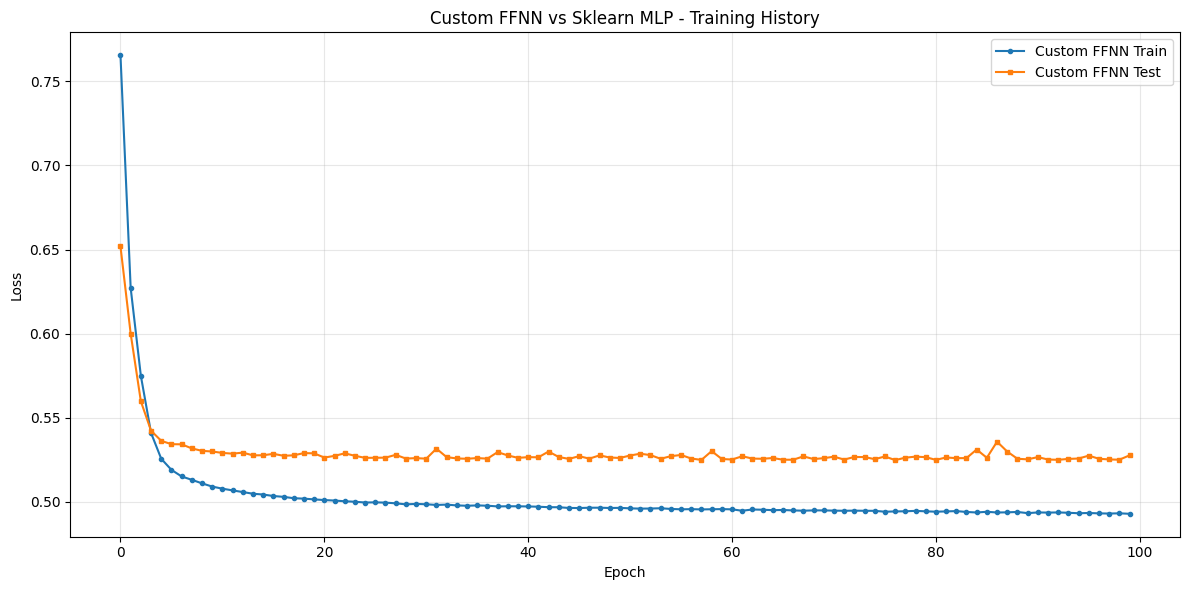

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(customHistory['train_loss'], label='Custom FFNN Train', marker='o', markersize=3)
ax.plot(customHistory['val_loss'], label='Custom FFNN Test', marker='s', markersize=3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Custom FFNN vs Sklearn MLP - Training History')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### END Wajib

#### Tambahan untuk Pengujian

#### Pengujian Inisialisasi Berbeda [6]]

Zero     - Acc: 0.6025, Prec: 0.6025, Rec: 1.0000, F1: 0.7520
Uniform  - Acc: 0.7330, Prec: 0.7498, Rec: 0.8357, F1: 0.7904
Normal   - Acc: 0.7346, Prec: 0.7484, Rec: 0.8430, F1: 0.7929
Xavier   - Acc: 0.7341, Prec: 0.7535, Rec: 0.8303, F1: 0.7900
He       - Acc: 0.7374, Prec: 0.7555, Rec: 0.8339, F1: 0.7928


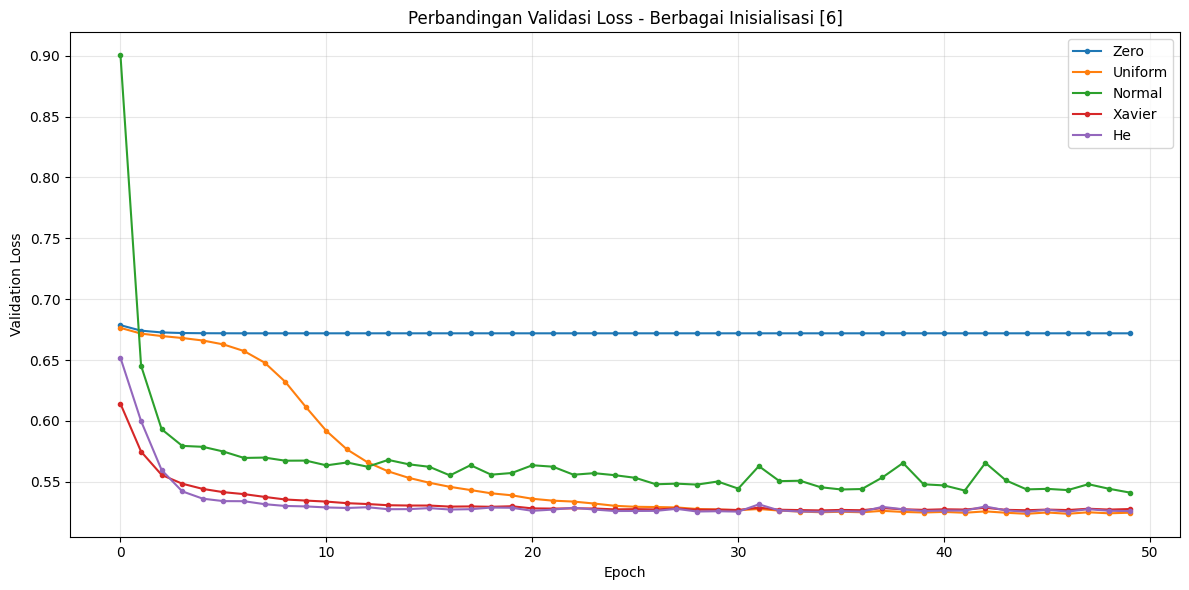

In [19]:
initResults = {}
initMethods = [
    ('Zero', ZeroInit()),
    ('Uniform', UniformInit(seed=42)),
    ('Normal', NormalInit(seed=42)),
    ('Xavier', XavierInit(seed=42)),
    ('He', HeInit(seed=42))
]

for initName, initializer in initMethods:
    model = FFNN(
        layer_sizes=modelConfig,
        activations=[ReLU(), ReLU(), Sigmoid()],
        loss=BinaryCrossEntropy(),
        initializer=initializer,
        regularizer=L2(0.001)
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
    ypr = model.predict(Xte)
    yclassPred = (ypr > 0.5).astype(int)
    
    acc = accuracy_score(yte, yclassPred)
    prec = precision_score(yte, yclassPred)
    rec = recall_score(yte, yclassPred)
    f1 = f1_score(yte, yclassPred)
    
    initResults[initName] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    
    print(f'{initName:8s} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
for initName, result in initResults.items():
    ax.plot(result['history']['val_loss'], label=f'{initName}', marker='o', markersize=3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Perbandingan Validasi Loss - Berbagai Inisialisasi [6]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#### Pengujian Inisialisasi Berbeda [7]

BCE Accuracy: 0.7374
MSE Accuracy: 0.7346


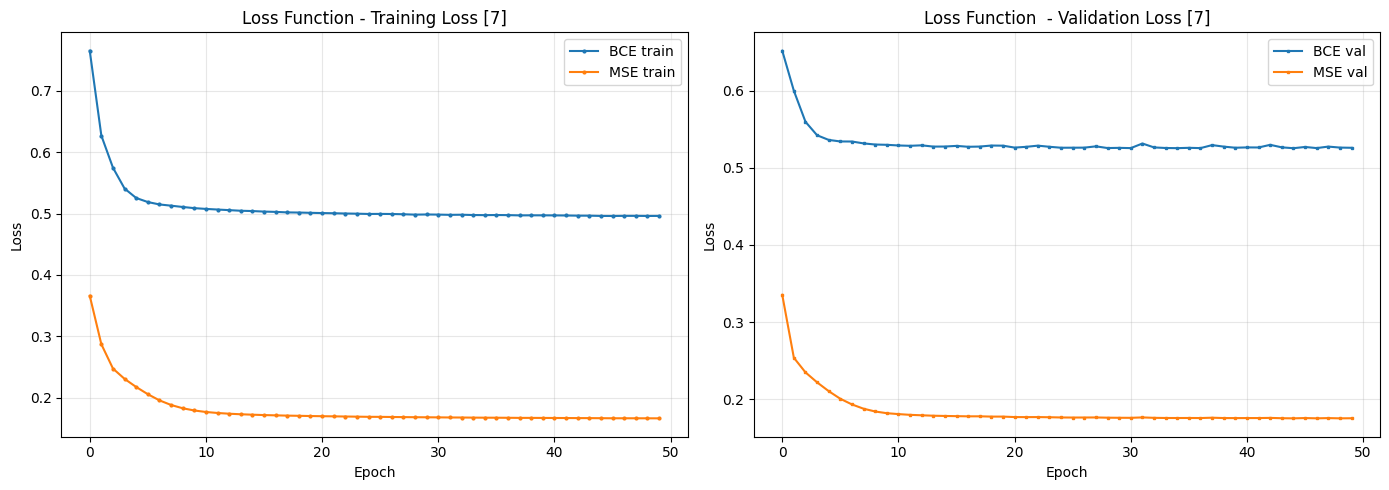


Perbandingan Loss Functions:
BCE: Accuracy = 0.7374
MSE: Accuracy = 0.7346


In [20]:
lossResults = {}

# BCE (Binary Cross Entropy) - sudah teruji
bceModel = FFNN(
    layer_sizes=modelConfig,
    activations=[ReLU(), ReLU(), Sigmoid()],
    loss=BinaryCrossEntropy(),
    initializer=HeInit(seed=42),
    regularizer=L2(0.001)
)
bceHistory = bceModel.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
bcePred = bceModel.predict(Xte)
bceClass = (bcePred > 0.5).astype(int)
bceAcc = accuracy_score(yte, bceClass)

lossResults['BCE'] = {
    'model': bceModel,
    'history': bceHistory,
    'accuracy': bceAcc
}

mseModel = FFNN(
    layer_sizes=modelConfig,
    activations=[ReLU(), ReLU(), Sigmoid()],
    loss=MSE(),
    initializer=HeInit(seed=42),
    regularizer=L2(0.001)
)
mseHistory = mseModel.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
msePred = mseModel.predict(Xte)
mseClass = (msePred > 0.5).astype(int)
mseAcc = accuracy_score(yte, mseClass)

lossResults['MSE'] = {
    'model': mseModel,
    'history': mseHistory,
    'accuracy': mseAcc
}

print(f'BCE Accuracy: {bceAcc:.4f}')
print(f'MSE Accuracy: {mseAcc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lossName, result in lossResults.items():
    axes[0].plot(result['history']['train_loss'], label=f'{lossName} train', marker='o', markersize=2)
    axes[1].plot(result['history']['val_loss'], label=f'{lossName} val', marker='s', markersize=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Function - Training Loss [7]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Function  - Validation Loss [7]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPerbandingan Loss Functions:')
for lossName, result in lossResults.items():
    print(f'{lossName}: Accuracy = {result["accuracy"]:.4f}')


#### Pengujian Inisialisasi Berbeda [8]


Best Model (He) - Weight Distribution:


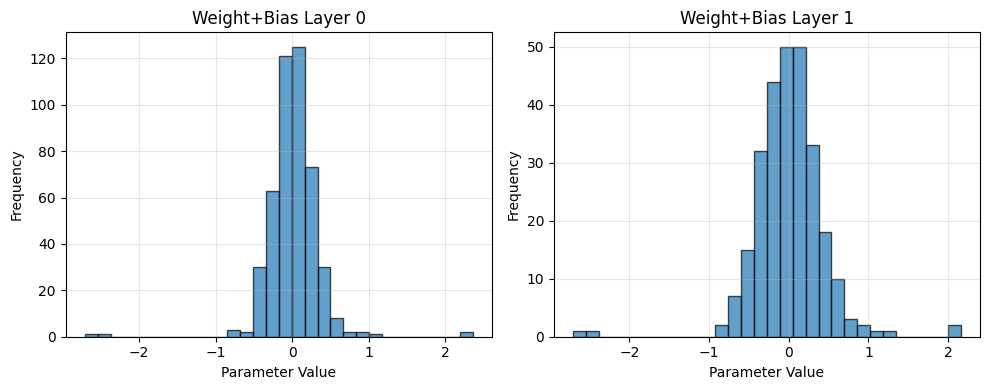


Best Model - Gradient Distribution:


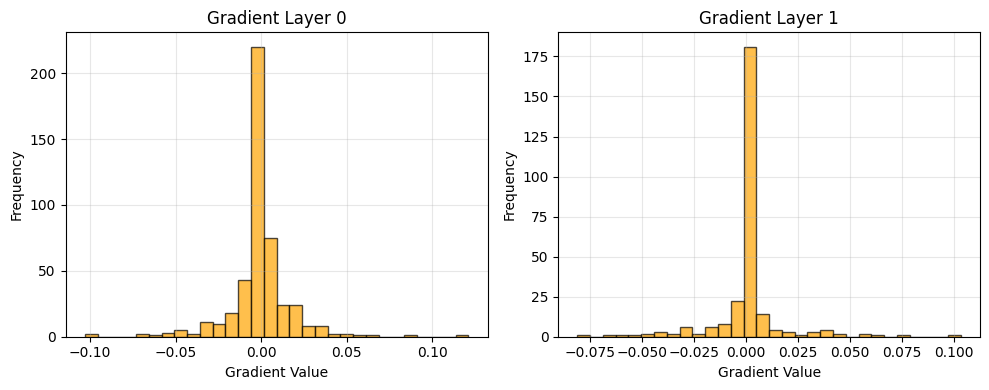


Best Model - Training History:


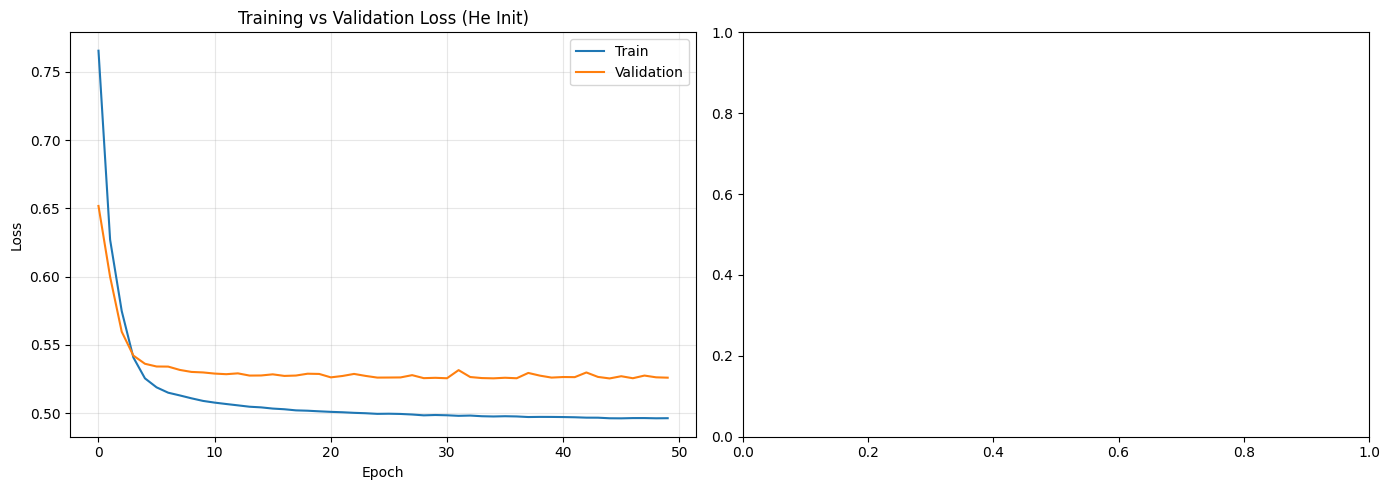

In [21]:
bestModel = initResults['He']['model']

print('\nBest Model (He) - Weight Distribution:')
bestModel.plotWeightDistribution(layerIndices=[0, 1])

print('\nBest Model - Gradient Distribution:')
bestModel.plotGradientDistribution(layerIndices=[0, 1])

print('\nBest Model - Training History:')
bestHistory = initResults['He']['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bestHistory['train_loss'])
axes[0].plot(bestHistory['val_loss'])
axes[0].set_title('Training vs Validation Loss (He Init)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Train', 'Validation'])
axes[0].grid(True, alpha=0.3)

if 'train_acc' in bestHistory:
    axes[1].plot(bestHistory['train_acc'])
    axes[1].plot(bestHistory['val_acc'])
    axes[1].set_title('Training vs Validation Accuracy (He Init)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(['Train', 'Validation'])
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Pengujian LeakyReLU dan ELU 

LeakyReLU    - Acc: 0.7374, Prec: 0.7551, Rec: 0.8348, F1: 0.7930
ELU          - Acc: 0.7325, Prec: 0.7488, Rec: 0.8366, F1: 0.7903


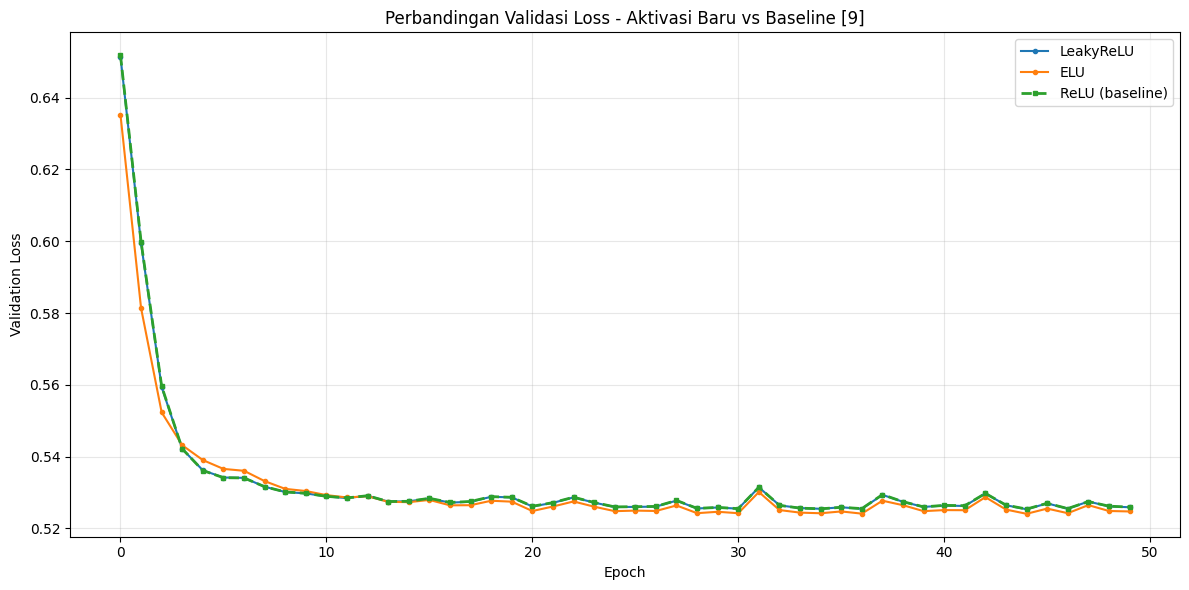

In [22]:
from ffnn.utils.activation_function import LeakyReLU, ELU

newActivationResults = {}
newActivationChoices = [
    ('LeakyReLU', LeakyReLU(alpha=0.01)),
    ('ELU', ELU(alpha=1.0))
]

for actName, act in newActivationChoices:
    model = FFNN(
        layer_sizes=baseConfig,
        activations=[act, ReLU(), Sigmoid()],
        loss=BinaryCrossEntropy(),
        initializer=HeInit(seed=42),
        regularizer=L2(0.001)
    )
    
    history = model.fit(Xtr, ytr, Xte, yte, epochs=50, lr=0.01, batch_size=32, verbose=0)
    ypr = model.predict(Xte)
    ypredClass = (ypr > 0.5).astype(int)
    
    acc = accuracy_score(yte, ypredClass)
    prec = precision_score(yte, ypredClass)
    rec = recall_score(yte, ypredClass)
    f1 = f1_score(yte, ypredClass)
    
    newActivationResults[actName] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    
    print(f'{actName:12s} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
for actName, result in newActivationResults.items():
    ax.plot(result['history']['val_loss'], label=f'{actName}', marker='o', markersize=3)
if 'ReLU' in activationResults:
    ax.plot(activationResults['ReLU']['history']['val_loss'], 
            label='ReLU (baseline)', marker='s', markersize=3, linestyle='--', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Perbandingan Validasi Loss - Aktivasi Baru vs Baseline [9]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()